In [2]:
import os
import sys

# 1. Force add typical cluster CUDA paths to the system environment
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/lib64:/usr/local/cuda/compat/lib.real:' + os.getenv('LD_LIBRARY_PATH', '')

# 2. Automatically link TensorFlow's internal directory to NVIDIA system paths
try:
    import tensorflow as tf
    import nvidia.cuda_nvcc
    print("Linking CUDA drivers to TensorFlow...")
    
    # Create symbolic links dynamically
    tf_path = os.path.dirname(tf.__file__)
    os.system(f"ln -svf /usr/local/cuda/lib64/libcuda.so* {tf_path}/")
    os.system(f"ln -svf /usr/local/cuda/lib64/libcudart.so* {tf_path}/")
    print("Symlinks created. Please restart your notebook kernel now!")
except ImportError:
    print("TensorFlow or NVIDIA packages not found.")


TensorFlow or NVIDIA packages not found.


In [3]:
!pip uninstall -y tensorflow
!pip install "tensorflow[and-cuda]==2.20.0"


Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.6/620.6 MB 10.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 11.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 155.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 76.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 52.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 141.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.8/720.8 MB 9.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 26.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 MB 52.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.1/338.1 MB 18.2 MB/s

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Load Fashion-MNIST Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Normalize Pixel Values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model on GPU
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_classes))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_classes))


Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


/usr/local/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7709 - loss: 0.6376 - val_accuracy: 0.8447 - val_loss: 0.4172
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8467 - loss: 0.4254 - val_accuracy: 0.8577 - val_loss: 0.3886
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8588 - loss: 0.3845 - val_accuracy: 0.8701 - val_loss: 0.3621
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8693 - loss: 0.3592 - val_accuracy: 0.8704 - val_loss: 0.3483
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8754 - loss: 0.3405 - val_accuracy: 0.8773 - val_loss: 0.3333
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8793 - loss: 0.3265 - val_accuracy: 0.8802 - val_loss: 0.3278
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8833 - loss: 0.3140 - val_accuracy: 0.8811 - val_loss: 0.3395
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8855 - loss: 0.3084 - val_accuracy: 0.

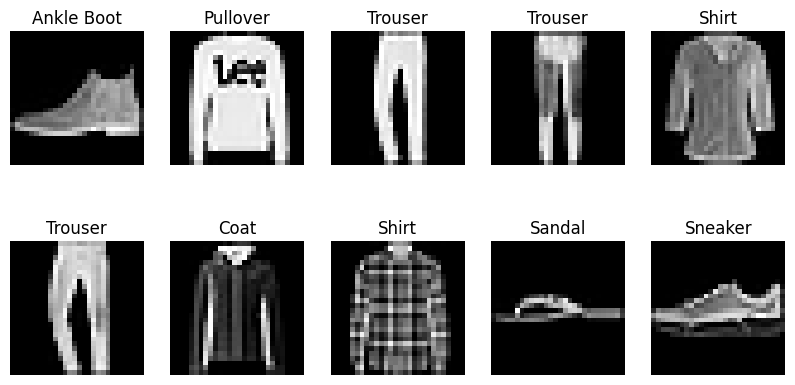

In [5]:
class_names = [
    'T-shirt','Trouser','Pullover','Dress',
    'Coat','Sandal','Shirt','Sneaker',
    'Bag','Ankle Boot'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(class_names[y_pred_classes[i]])
    plt.axis('off')

plt.show()
